In [26]:
import sys
import os
from datetime import datetime


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlflow.tracking import MlflowClient

from tqdm import tqdm

sys.path.append("../.")


pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 400)
pd.set_option("display.float_format", lambda x: "%.4f" % x)


%reload_ext autoreload
%autoreload 2

### RDL Compatible RDBs


In [27]:
dataset_df = pd.read_csv("../redelex/datasets/dataset-info.csv", index_col="dataset")
col_map = {
    "n_tables": "#Tab.",
    "n_fks": "#FK",
    "n_factual_cols": "#Factual",
    "total_n_tuples": "#Rows",
    "total_n_fk_edges": "#Links",
    "schema_diameter": "Schema Diameter",
    "has_loops": "Has Loops",
    # "one_to_one": "one-to-one",
    # "one_to_many": "one-to-many",
    # "many_to_one": "many-to-one",
    # "is_link_table": "many-to-many",
    # "like_many_to_many": "#Hubs",
    "domain": "Domain",
    # "is_artificial": "Is Artificial",
    # "db_size_MB": "Size (MB)",
    # "mlt_cat_col": "#mlt.cat.",
    "cat_col": "#cat",
    "num_col": "#num",
    "text_col": "#text",
    "time_col": "#time",
}

dataset_df = dataset_df.rename(columns=col_map)[col_map.values()].sort_index()

In [ ]:
selected_dbs = [
    # "rel-amazon",
    # "rel-avito",
    "rel-f1",
    "rel-stack",
]

selected_info = dataset_df.loc[selected_dbs].sort_index()
# selected_info["one-to-one"] = selected_info["one-to-one"] // 2
selected_info.to_latex("./data/tables/selected_datasets.tex", float_format="%.2f")
selected_info

,#Tab.,#FK,#Factual,#Rows,#Links,Schema Diameter,Has Loops,Domain,#cat,#num,#text,#time
dataset,,,,,,,,,,,,
rel-f1,9,13,45,97606,227716,3,True,Sport,16,13,9,7
rel-stack,7,12,33,5399818,7453492,3,True,Education,10,1,13,7


### Overall Results


In [ ]:
# Initialize MLflow Client
client = MlflowClient(tracking_uri="http://potato.felk.cvut.cz:2222")

experiment_names = [
    "pelesjak_linear_sage_pretrain",
    "pelesjak_resnet_sage_pretrain",
    "pelesjak_linear_sage_nopretrain",
    "pelesjak_resnet_sage_nopretrain",
]

for experiment_name in experiment_names:
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")
    experiment_id = experiment.experiment_id

    # Get all runs for the experiment
    runs = client.search_runs(experiment_ids=[experiment_id], max_results=10000)

    runs_dict = []
    for r in tqdm(runs.to_list()):
        r_info = r.info.__dict__
        r_data = {k: v for d in r.data.to_dictionary().values() for k, v in d.items()}

        runs_dict.append({**r_info, **r_data})

    df = pd.DataFrame(runs_dict)

    df.to_csv(f"./data/{experiment_name}.csv")

100%|██████████| 95/95 [00:00<00:00, 274799.23it/s]


In [31]:
best_dict: dict[str, pd.DataFrame] = {}

exp_names_pretrain = ["pelesjak_linear_sage_pretrain", "pelesjak_resnet_sage_pretrain"]
exp_names_nopretrain = [
    "pelesjak_linear_sage_nopretrain",
    "pelesjak_resnet_sage_nopretrain",
]

exp_names = exp_names_pretrain + exp_names_nopretrain
dfs = []
for exp_name in exp_names:
    df = pd.read_csv(f"./{exp_name}.csv", index_col=0)
    df["model_type"] = "_".join(exp_name.split("_")[1:])
    dfs.append(df)

df = pd.concat(dfs, axis=0).reset_index(drop=True)
df["_start_time"] = pd.to_datetime(df["_start_time"], unit="ms")
df["_end_time"] = pd.to_datetime(df["_end_time"], unit="ms")
df["duration"] = (df["_end_time"] - df["_start_time"]).dt.total_seconds()
df = df[df["_start_time"] > datetime(2025, 6, 16, hour=16)]

In [32]:
cols = df.columns
cols_map = {c: c.lstrip("_") for c in cols}
df = df.rename(columns=cols_map)
df = df[[c for c in df.columns if not c.startswith("mlflow.")]]
len(df)

715

In [ ]:
start_dirs_linear = [
    "../logs/linear_sage_pretrain_10092547",
    "../logs/linear_sage_pretrain_10092874",
    "../logs/linear_sage_pretrain_10092881",
    "../logs/linear_sage_pretrain_10093354",
]
start_dirs_resnet = [
    "../logs/resnet_sage_pretrain_10092542",
    "../logs/resnet_sage_pretrain_10092878",
    "../logs/resnet_sage_pretrain_10092882",
    "../logs/resnet_sage_pretrain_10093358",
]


def get_task_mapping(start_dirs: list[str]):
    task_mapping = {}
    for start_dir in start_dirs:
        for task_name in os.listdir(start_dir):
            if not os.path.isdir(os.path.join(start_dir, task_name)):
                continue
            task_name_dir = os.path.join(start_dir, task_name)
            task_task_dir = [
                d
                for d in os.listdir(task_name_dir)
                if os.path.isdir(os.path.join(task_name_dir, d))
            ][0]
            task_dir = os.path.join(task_name_dir, task_task_dir)
            parent_tasks = [
                d for d in os.listdir(task_dir) if os.path.isdir(os.path.join(task_dir, d))
            ]

            for parent_task in parent_tasks:
                parent_task_dir = os.path.join(task_dir, parent_task)
                parent_task_task = [
                    d
                    for d in os.listdir(parent_task_dir)
                    if os.path.isdir(os.path.join(parent_task_dir, d))
                ]
                if len(parent_task_task) == 0:
                    continue
                parent_task_dir = os.path.join(parent_task_dir, parent_task_task[0])
                child_tasks = [
                    d
                    for d in os.listdir(parent_task_dir)
                    if os.path.isdir(os.path.join(parent_task_dir, d))
                ]
                # print(child_tasks[0].split("_"))
                _child_tasks = []
                for c in child_tasks:
                    if c.startswith("run_pretrained"):
                        _child_tasks.append("_".join(c.split("_")[4:6]))
                    else:
                        _child_tasks.append("_".join(c.split("_")[3:5]))

                task_mapping[parent_task] = _child_tasks
    return task_mapping


task_mapping = get_task_mapping(start_dirs_linear + start_dirs_resnet)
rever_task_mapping = {}
for k, v in task_mapping.items():
    for vv in v:
        rever_task_mapping[vv] = k

In [38]:
df["run_id"] = (
    df["run_name"]
    .str.replace("run_task_experiment_", "")
    .str.replace("_pretrain", "")
    .str.replace(r"rel-[0-9,a-z]*_", "", regex=True)
)

In [39]:
df["parent_task"] = df["run_id"].map(rever_task_mapping)
# df["child_tasks"] = df["run_id"].map(task_mapping)

In [40]:
child_df = df.merge(
    df, left_on="parent_task", right_on="run_id", suffixes=("", "_parent"), how="left"
).dropna(axis=1, how="all")

In [41]:
child_df["dataset"].isin(["rel-f1", "rel-stack"]).value_counts()

dataset
True     571
False    144
Name: count, dtype: int64

In [42]:
child_df = child_df.loc[child_df["dataset"].isin(["rel-f1", "rel-stack"])]

In [ ]:
groupby_results = child_df.groupby(
    [
        "dataset",
        "task",
        # "with_neighbor_pretrain_parent",
        "finetune_backbone",
        "model_type",
        # "corrupt_prob_parent",
        # "rgnn_layers",
        # "rgnn_aggr"
    ]
)


cls_idx = groupby_results["best_val_roc_auc"].transform(max) == child_df["best_val_roc_auc"]
reg_idx = groupby_results["best_val_mae"].transform(min) == child_df["best_val_mae"]
groupby_results[
    ["best_val_roc_auc", "best_test_roc_auc", "best_val_mae", "best_test_mae"]
].aggregate(["size", "min", "max", "mean", "median", "std"])

/tmp/ipykernel_58834/2281773988.py:15: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  cls_idx = groupby_results["best_val_roc_auc"].transform(max) == child_df["best_val_roc_auc"]
/tmp/ipykernel_58834/2281773988.py:16: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  reg_idx = groupby_results["best_val_mae"].transform(min) == child_df["best_val_mae"]


best_val_roc_auc  \
                                                                               size   
dataset   task            finetune_backbone model_type                                
rel-f1    driver-dnf      False             linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 25   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                 24   
                          True              linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 24   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                 23   
          driver-position False             linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 26   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                 24   
                          True              linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 25   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                 24   
          driver-top3     False             linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 21   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                 20   
                          True              linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 19   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                 20   
rel-stack post-votes      False             linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 11   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                 10   
                          True              linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 11   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                  9   
          user-badge      False             linear_sage_nopretrain                4   
                                            linear_sage_pretrain                  8   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                  7   
                          True              linear_sage_nopretrain                4   
                                            linear_sage_pretrain                  8   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain                  6   
          user-engagement False             linear_sage_nopretrain                4   
                                            linear_sage_pretrain                 12   
                                            resnet_sage_nopretrain                4   
                                            resnet_sage_pretrain 

In [ ]:
cls_results = child_df.loc[
    cls_idx,
    [
        "dataset",
        "task",
        "model_type",
        "finetune_backbone",
        "best_val_roc_auc",
        "best_test_roc_auc",
    ],
].sort_values(
    by=["dataset", "task", "model_type", "finetune_backbone"],
)

cls_results_val = cls_results.copy(deep=True)
cls_results_test = cls_results.copy(deep=True)
cls_results_val["roc_auc"] = cls_results_val["best_val_roc_auc"]
cls_results_val["split"] = "val"
cls_results_test["roc_auc"] = cls_results_test["best_test_roc_auc"]
cls_results_test["split"] = "test"
cls_results = pd.concat([cls_results_val, cls_results_test], axis=0).reset_index(drop=True)


cls_results["pretrain"] = ~cls_results["model_type"].str.contains("nopretrain")
cls_results["model_type"] = cls_results["model_type"].str.replace(
    r"_(no)?pretrain", "", regex=True
)
cls_results = cls_results[cls_results["finetune_backbone"] | cls_results["pretrain"]]

cls_results.set_index(
    ["dataset", "task", "split", "model_type", "pretrain", "finetune_backbone"],
    inplace=True,
)
cls_results = (
    cls_results.unstack(level=["pretrain", "finetune_backbone", "model_type"], sort=True)[
        "roc_auc"
    ]
    .swaplevel(0, 2, axis=1)[["linear_sage", "resnet_sage"]]
    .sort_index(level=[0, 1, 2], ascending=[True, True, False])
) * 100

cls_results.to_latex(
    "./data/tables/cls_results.tex",
    float_format="%.2f",
    escape=True,
    index=True,
    multicolumn=True,
    multirow=True,
)
cls_results

model_type                      linear_sage                 resnet_sage  \
finetune_backbone                     True    False   True        True    
pretrain                              False   True    True        False   
dataset   task            split                                           
rel-f1    driver-dnf      val       72.9107 74.3891 73.2499     74.6921   
                          test      75.5839 72.9342 73.7637     78.0745   
          driver-top3     val       78.0187 79.6689 78.9092     77.4023   
                          test      84.6010 79.1636 82.2364     84.5749   
rel-stack user-badge      val       89.3476 87.7162 89.6268     89.2942   
                          test      88.1184 85.9578 88.5092     87.8870   
          user-engagement val       90.0218 86.9290 90.0792     89.9371   
                          test      90.3421 86.9946 90.4662     90.2762   

model_type                                       
finetune_backbone                 False   True   
pretrain                          True    True   
dataset   task            split                  
rel-f1    driver-dnf      val   74.5941 78.3492  
                          test  76.5715 78.6854  
          driver-top3     val   82.5124 82.1630  
                          test  82.1083 71.3694  
rel-stack user-badge      val   87.2450 89.4576  
                          test  85.5574 88.2111  
          user-engagement val   87.0617 90.1780  
                          test  86.5494 90.3194

In [ ]:
reg_results = child_df.loc[
    reg_idx,
    [
        "dataset",
        "task",
        "model_type",
        "finetune_backbone",
        "best_val_mae",
        "best_test_mae",
    ],
].sort_values(
    by=["dataset", "task", "model_type", "finetune_backbone"],
)


reg_results["pretrain"] = ~reg_results["model_type"].str.contains("nopretrain")
reg_results["model_type"] = reg_results["model_type"].str.replace(
    r"_(no)?pretrain", "", regex=True
)
reg_results = reg_results[reg_results["finetune_backbone"] | reg_results["pretrain"]]


reg_results_val = reg_results.copy(deep=True)
reg_results_test = reg_results.copy(deep=True)
reg_results_val["mae"] = reg_results_val["best_val_mae"]
reg_results_val["split"] = "val"
reg_results_test["mae"] = reg_results_test["best_test_mae"]
reg_results_test["split"] = "test"
reg_results = pd.concat([reg_results_val, reg_results_test], axis=0).reset_index(drop=True)


reg_results.set_index(
    ["dataset", "task", "split", "model_type", "pretrain", "finetune_backbone"],
    inplace=True,
)
reg_results = (
    reg_results.unstack(level=["pretrain", "finetune_backbone", "model_type"])["mae"]
    .swaplevel(0, 2, axis=1)[["linear_sage", "resnet_sage"]]
    .sort_index(level=[0, 1, 2], ascending=[True, True, False])
)


reg_results.to_latex(
    "./data/tables/reg_results.tex",
    float_format="%.3f",
    escape=True,
    index=True,
    multicolumn=True,
    multirow=True,
)
reg_results

model_type                      linear_sage               resnet_sage         \
finetune_backbone                     True   False  True        True   False   
pretrain                              False  True   True        False  True    
dataset   task            split                                                
rel-f1    driver-position val        3.2015 3.2265 3.1183      3.1134 3.2076   
                          test       3.6858 3.4239 3.5910      3.3290 3.5806   
rel-stack post-votes      val        0.0993 0.1042 0.0794      0.0893 0.1022   
                          test       0.1055 0.1099 0.0856      0.0954 0.1081   

model_type                              
finetune_backbone                True   
pretrain                         True   
dataset   task            split         
rel-f1    driver-position val   3.0763  
                          test  3.3939  
rel-stack post-votes      val   0.0847  
                          test  0.0898

In [ ]:
cls_child_df = child_df[
    child_df["task"].isin(["driver-dnf", "driver-top3", "user-badge", "user-engagement"])
].reset_index(drop=True)
cls_child_grouped = cls_child_df.groupby(
    [
        "dataset",
        "task",
        "finetune_backbone",
        "model_type",
    ]
)

cls_idx = (
    cls_child_grouped["best_val_roc_auc"].transform(
        lambda x: x.sort_values(ascending=False).iloc[:5].min()
    )
    <= cls_child_df["best_val_roc_auc"]
)

cls_results = (
    cls_child_df.loc[
        cls_idx,
        [
            "dataset",
            "task",
            "model_type",
            "finetune_backbone",
            "best_val_roc_auc",
            "best_test_roc_auc",
        ],
    ]
    .sort_values(
        by=["dataset", "task", "model_type", "finetune_backbone"],
    )
    .groupby(["dataset", "task", "finetune_backbone", "model_type"])
    .aggregate(["mean", "std"])
)
cls_results.columns = [
    "_".join(col) if isinstance(col, tuple) else col for col in cls_results.columns
]

cls_results_val = cls_results.copy(deep=True)
cls_results_test = cls_results.copy(deep=True)
cls_results_val["roc_auc"] = cls_results_val["best_val_roc_auc_mean"]
cls_results_val["std"] = cls_results_val["best_val_roc_auc_std"]
cls_results_val["split"] = "val"
cls_results_test["roc_auc"] = cls_results_test["best_test_roc_auc_mean"]
cls_results_test["std"] = cls_results_test["best_test_roc_auc_std"]
cls_results_test["split"] = "test"
cls_results = pd.concat([cls_results_val, cls_results_test], axis=0).reset_index()

cls_results["pretrain"] = ~cls_results["model_type"].str.contains("nopretrain")
cls_results["model_type"] = cls_results["model_type"].str.replace(
    r"_(no)?pretrain", "", regex=True
)
cls_results = cls_results[cls_results["finetune_backbone"] | cls_results["pretrain"]]

cls_results.set_index(
    ["dataset", "task", "split", "model_type", "pretrain", "finetune_backbone"],
    inplace=True,
)

cls_results = (
    cls_results.unstack(level=["pretrain", "finetune_backbone", "model_type"], sort=True)[
        ["roc_auc", "std"]
    ]
    .swaplevel(0, 3, axis=1)[["linear_sage", "resnet_sage"]]
    .sort_index(level=[0, 1, 2], ascending=[True, True, False])
) * 100

cls_results = cls_results[sorted([c for c in cls_results.columns])]
cls_results.to_latex(
    "./data/tables/cls_results_top5.tex",
    float_format="%.3f",
    escape=True,
    index=True,
    multicolumn=True,
    multirow=True,
)
cls_results

model_type                      linear_sage                                \
pretrain                              False          True                   
finetune_backbone                     True           False          True    
                                    roc_auc    std roc_auc    std roc_auc   
dataset   task            split                                             
rel-f1    driver-dnf      val       72.4204 0.5649 73.8467 0.4879 73.0518   
                          test      76.5332 0.6994 75.5766 2.0404 74.3924   
          driver-top3     val       76.5113 1.1454 79.0102 0.5315 77.5152   
                          test      84.1150 0.7171 82.4425 2.4407 80.9208   
rel-stack user-badge      val       88.8495 0.5549 87.2778 0.3484 89.0872   
                          test      87.6158 0.6115 85.6965 0.1592 87.9254   
          user-engagement val       89.4095 0.4967 86.6394 0.4152 89.9468   
                          test      89.7094 0.5547 86.3474 0.6646 90.2836   

model_type                             resnet_sage                        \
pretrain                                     False          True           
finetune_backbone                            True           False          
                                   std     roc_auc    std roc_auc    std   
dataset   task            split                                            
rel-f1    driver-dnf      val   0.1905     71.6349 2.2669 74.1333 0.3824   
                          test  2.3699     77.7817 0.3448 75.5509 1.0936   
          driver-top3     val   0.9541     75.5681 2.3818 79.2450 1.8994   
                          test  4.4655     85.2133 1.0100 82.0924 0.8089   
rel-stack user-badge      val   0.3992     88.8210 0.4594 86.9696 0.2203   
                          test  0.4475     87.5958 0.4109 85.2634 0.3483   
          user-engagement val   0.1676     89.3294 0.6149 86.2947 0.6362   
                          test  0.2374     89.5886 0.6083 85.9161 0.5218   

model_type                                      
pretrain                                        
finetune_backbone                 True          
                                roc_auc    std  
dataset   task            split                 
rel-f1    driver-dnf      val   76.5047 1.2306  
                          test  76.8109 2.2929  
          driver-top3     val   80.9507 0.7994  
                          test  79.9301 4.9188  
rel-stack user-badge      val   89.1771 0.3167  
                          test  87.9999 0.2356  
          user-engagement val   90.0336 0.2623  
                          test  90.2747 0.3161

In [ ]:
reg_child_df = child_df[
    child_df["task"].isin(["driver-position", "post-votes"])
].reset_index(drop=True)
reg_child_grouped = reg_child_df.groupby(
    [
        "dataset",
        "task",
        "finetune_backbone",
        "model_type",
    ]
)

reg_idx = (
    reg_child_grouped["best_val_mae"].transform(
        lambda x: x.sort_values(ascending=True).iloc[:5].max()
    )
    >= reg_child_df["best_val_mae"]
)

reg_results = (
    reg_child_df.loc[
        reg_idx,
        [
            "dataset",
            "task",
            "model_type",
            "finetune_backbone",
            "best_val_mae",
            "best_test_mae",
        ],
    ]
    .sort_values(
        by=["dataset", "task", "model_type", "finetune_backbone"],
    )
    .groupby(["dataset", "task", "finetune_backbone", "model_type"])
    .aggregate(["mean", "std"])
)
reg_results.columns = [
    "_".join(col) if isinstance(col, tuple) else col for col in reg_results.columns
]

reg_results_val = reg_results.copy(deep=True)
reg_results_test = reg_results.copy(deep=True)
reg_results_val["mae"] = reg_results_val["best_val_mae_mean"]
reg_results_val["std"] = reg_results_val["best_val_mae_std"]
reg_results_val["split"] = "val"
reg_results_test["mae"] = reg_results_test["best_test_mae_mean"]
reg_results_test["std"] = reg_results_test["best_test_mae_std"]
reg_results_test["split"] = "test"
reg_results = pd.concat([reg_results_val, reg_results_test], axis=0).reset_index()

reg_results["pretrain"] = ~reg_results["model_type"].str.contains("nopretrain")
reg_results["model_type"] = reg_results["model_type"].str.replace(
    r"_(no)?pretrain", "", regex=True
)
reg_results = reg_results[reg_results["finetune_backbone"] | reg_results["pretrain"]]

reg_results.set_index(
    ["dataset", "task", "split", "model_type", "pretrain", "finetune_backbone"],
    inplace=True,
)

reg_results = (
    reg_results.unstack(level=["pretrain", "finetune_backbone", "model_type"], sort=True)[
        ["mae", "std"]
    ]
    .swaplevel(0, 3, axis=1)[["linear_sage", "resnet_sage"]]
    .sort_index(level=[0, 1, 2], ascending=[True, True, False])
)

reg_results = reg_results[sorted([c for c in reg_results.columns])]
reg_results.to_latex(
    "./data/tables/reg_results_top5.tex",
    float_format="%.3f",
    escape=True,
    index=True,
    multicolumn=True,
    multirow=True,
)
reg_results

model_type                      linear_sage                              \
pretrain                              False         True                  
finetune_backbone                     True          False         True    
                                        mae    std    mae    std    mae   
dataset   task            split                                           
rel-f1    driver-position val        3.3172 0.1815 3.2738 0.0369 3.1746   
                          test       3.5866 0.1958 3.5956 0.1620 3.5538   
rel-stack post-votes      val        0.1073 0.0058 0.1095 0.0058 0.0842   
                          test       0.1130 0.0054 0.1149 0.0053 0.0902   

model_type                             resnet_sage                       \
pretrain                                     False         True           
finetune_backbone                            True          False          
                                   std         mae    std    mae    std   
dataset   task            split                                           
rel-f1    driver-position val   0.0341      3.5490 0.5359 3.2285 0.0166   
                          test  0.1379      3.8711 0.5673 3.6380 0.1698   
rel-stack post-votes      val   0.0033      0.1076 0.0146 0.1087 0.0042   
                          test  0.0032      0.1127 0.0141 0.1142 0.0040   

model_type                                     
pretrain                                       
finetune_backbone                True          
                                   mae    std  
dataset   task            split                
rel-f1    driver-position val   3.1007 0.0244  
                          test  3.4690 0.1104  
rel-stack post-votes      val   0.0910 0.0043  
                          test  0.0960 0.0042

In [ ]:
duration_df = child_df[child_df["duration"].notna()]
duration_df = duration_df.groupby(
    [
        "dataset",
        "task",
        # "with_neighbor_pretrain_parent",
        "finetune_backbone",
        "model_type",
        # "corrupt_prob_parent",
        "rgnn_layers",
    ]
)[["duration", "duration_parent"]].aggregate("mean")

duration_df = duration_df.reset_index()


duration_df["pretrain"] = ~duration_df["model_type"].str.contains("nopretrain")
duration_df["model_type"] = duration_df["model_type"].str.replace(
    r"_(no)?pretrain", "", regex=True
)
duration_df = duration_df[duration_df["finetune_backbone"] | duration_df["pretrain"]]


duration_df.set_index(
    ["dataset", "task", "model_type", "pretrain", "finetune_backbone", "rgnn_layers"],
    inplace=True,
)
duration_df = (
    duration_df.unstack(level=["pretrain", "finetune_backbone"])
    .swaplevel(0, 2, axis=1)
    # .swaplevel(1, 3, axis=1)
    .sort_index(level=[0, 1, 2], ascending=[True, True, True])
)

duration_df = duration_df[sorted([c for c in duration_df.columns])]

# duration_df = duration_df.groupby(
#     ["dataset", "task", "rgnn_layers"]
# ).aggregate("mean")
# duration_df = duration_df.reset_index()
# duration_sum_df = duration_df.groupby(["dataset", "rgnn_layers"]).aggregate("sum")
# duration_sum_df = duration_sum_df.reset_index()
# duration_sum_df["task"] = "_total"
# duration_df = pd.concat([duration_df, duration_sum_df], axis=0).reset_index(drop=True)


# duration_df = duration_df.set_index(["dataset", "task", "rgnn_layers"]).sort_index(
#     level=[0, 1, 2], ascending=[True, True, True]
# )

duration_df  # .loc[(slice(None), slice(None), slice(None), 2), (True, False, "duration")].to_dict()

finetune_backbone                                      False                  \
pretrain                                               True                    
                                                    duration duration_parent   
dataset   task            model_type  rgnn_layers                              
rel-f1    driver-dnf      linear_sage 2             432.7276       2218.9225   
                                      3            7415.4061       2062.5246   
                          resnet_sage 2             612.5178       1571.1363   
                                      3            7563.9801       1291.6291   
          driver-position linear_sage 2             378.2350       2240.6815   
                                      3            7422.9391       2062.5246   
                          resnet_sage 2             597.7549       1571.1363   
                                      3            7481.2007       1291.6291   
          driver-top3     linear_sage 2             174.5964       2218.9225   
                                      3            4962.5987       1630.8871   
                          resnet_sage 2             247.5676       1573.5733   
                                      3            6686.7697        985.6070   
rel-stack post-votes      linear_sage 2            7777.8472        891.1779   
                                      3           15253.7180        797.6350   
                          resnet_sage 2            7893.8599        612.6089   
                                      3           17751.4050        951.9120   
          user-badge      linear_sage 2            5283.4520        887.4150   
                                      3            7862.0700        797.6350   
                          resnet_sage 2            6856.3195        552.9227   
                                      3                  NaN             NaN   
          user-engagement linear_sage 2            5284.9977        891.1779   
                                      3            7678.2413       1436.9552   
                          resnet_sage 2            6383.4383        896.6705   
                                      3            7834.7930        815.0013   

finetune_backbone                                      True                   \
pretrain                                               False                   
                                                    duration duration_parent   
dataset   task            model_type  rgnn_layers                              
rel-f1    driver-dnf      linear_sage 2            1043.7025             NaN   
                                      3            7546.2520             NaN   
                          resnet_sage 2            2176.4025             NaN   
                                      3            7639.5630             NaN   
          driver-position linear_sage 2             737.4835             NaN   
                                      3            7585.6095             NaN   
                          resnet_sage 2            1409.4590             NaN   
                                      3            7700.1550             NaN   
          driver-top3     linear_sage 2             309.5940             NaN   
                                      3            6214.0965             NaN   
                          resnet_sage 2             451.2795             NaN   
                                      3            7758.0370             NaN   
rel-stack post-votes      linear_sage 2            7921.2755             NaN   
                                      3           12223.9310             NaN   
                          resnet_sage 2            8619.8335             NaN   
                                      3           17414.8325             NaN   
          user-badge      linear_sage 2            7493.0010             NaN   
                                      3            7612.9790             NaN   

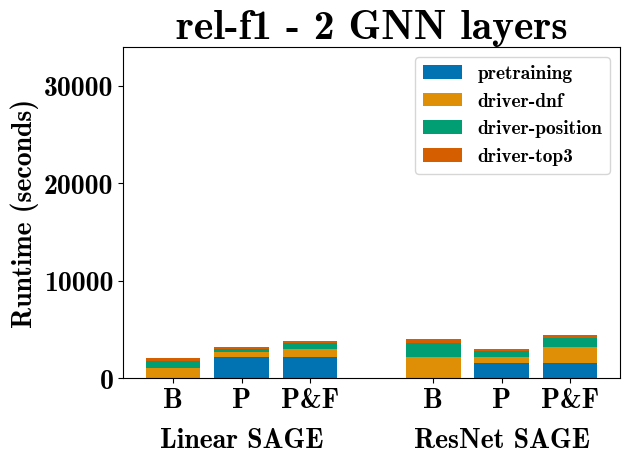

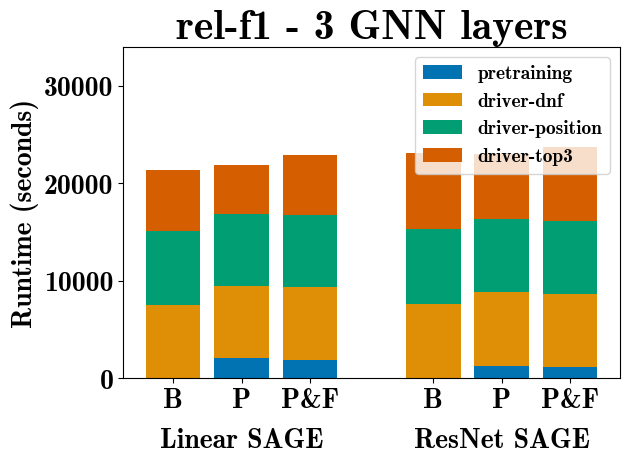

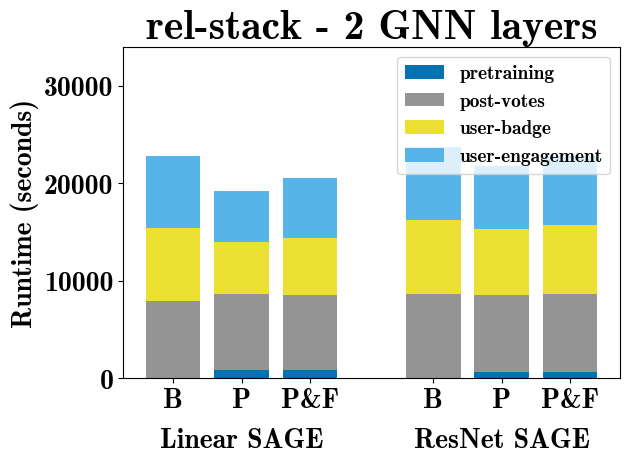

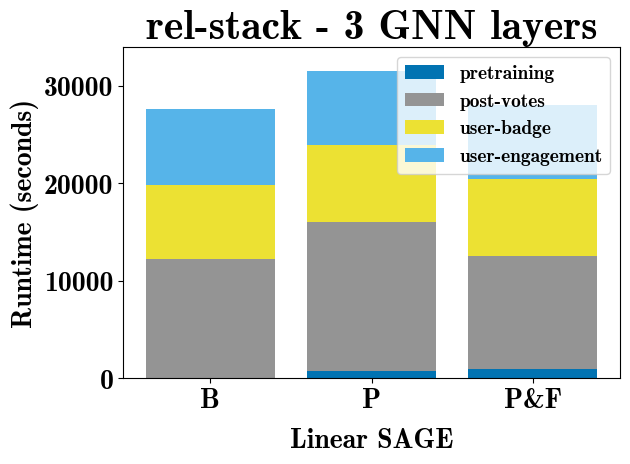

In [63]:
# Data setup
dataset_labels = duration_df.index.get_level_values(0).unique().tolist()
task_labels = {
    d: duration_df.loc[d].index.get_level_values(0).unique().tolist()
    for d in dataset_labels
}
model_types = duration_df.index.get_level_values(2).unique().tolist()

# Data: different number of subcategories per main group


def plot_duration(dataset_name, num_layers, color_offset=6):
    data = {}

    for model_type in model_types:
        if model_type == "resnet_sage" and dataset_name == "rel-stack" and num_layers == 3:
            continue
        data[model_type] = {}
        data[model_type]["B"] = [0] + [
            duration_df.loc[
                (dataset_name, task, model_type, num_layers), (True, False, "duration")
            ]
            for task in task_labels[dataset_name]
        ]
        data[model_type]["P"] = [
            duration_df.loc[
                (dataset_name, task_labels[dataset_name][0], model_type, num_layers),
                (False, True, "duration_parent"),
            ]
        ] + [
            duration_df.loc[
                (dataset_name, task, model_type, num_layers), (False, True, "duration")
            ]
            for task in task_labels[dataset_name]
        ]
        data[model_type]["P&F"] = [
            duration_df.loc[
                (dataset_name, task_labels[dataset_name][0], model_type, num_layers),
                (True, True, "duration_parent"),
            ]
        ] + [
            duration_df.loc[
                (dataset_name, task, model_type, num_layers), (True, True, "duration")
            ]
            for task in task_labels[dataset_name]
        ]
    width_multiplier = 0.1
    # Configs
    bar_width = 0.1 * width_multiplier
    bar_gap = 0.025 * width_multiplier
    spacing_between_groups = 0.1 * width_multiplier

    # Data containers
    positions = []
    stack_vals = [[] for _ in task_labels[dataset_name]]
    stack_vals.append([])  # For the pretraining
    level1_labels = []
    tick_labels = []

    current_x = 0
    for model_type, model_data in data.items():
        for model_name, vals in model_data.items():
            positions.append(current_x)
            stack_vals[0].append(vals[0])
            for i, v in enumerate(vals[1:]):
                stack_vals[i + 1].append(v)
            level1_labels.append(model_type)
            tick_labels.append(model_name)
            current_x += bar_width + bar_gap

        # Add small space between subgroups
        current_x += spacing_between_groups

    # Plot
    fig, ax = plt.subplots()
    labels = [task_label for task_label in task_labels[dataset_name]]
    # Plot base and stacked bars
    bottom = np.array(stack_vals[0])
    for i, vals in enumerate(stack_vals):
        if i == 0:
            ax.bar(
                positions,
                np.array(vals),
                width=bar_width,
                label="pretraining",
                color=sns.color_palette("colorblind", 20)[0],
            )
        else:
            ax.bar(
                positions,
                np.array(vals),
                width=bar_width,
                bottom=bottom,
                label=labels[i - 1],
                color=sns.color_palette("colorblind", 20)[i + color_offset],
            )
            bottom += np.array(vals)

    # Set bottom-level tick labels (Model names)
    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, ha="center")

    # --- Level 1: Group labels (centered across all their subgroups/models) ---
    group_positions = {}
    for i, group in enumerate(level1_labels):
        if group not in group_positions:
            group_positions[group] = []
        group_positions[group].append(positions[i])

    for group, pos_list in group_positions.items():
        center = np.mean(pos_list)
        ax.text(
            center,
            -0.15,
            group.replace("_", " ")
            .replace("sage", "SAGE")
            .replace("resnet", "ResNet")
            .replace("linear", "Linear"),
            ha="center",
            va="top",
            fontsize=20,
            fontweight="bold",
            transform=ax.get_xaxis_transform(),
        )

    # Final touches
    ax.set_ylabel("Runtime (seconds)", fontsize=20)
    ax.set_title(
        f"{dataset_name} - {num_layers} GNN layers",
        fontsize=30,
    )
    ax.legend(loc="upper right", fontsize=14)
    ax.set_ylim(0, 34000)
    ax.tick_params(axis="both", which="major", labelsize=20)

    plt.tight_layout()
    plt.savefig(
        f"duration_{dataset_name}_layers_{num_layers}.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()


plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "cmb10"
plot_duration("rel-f1", 2, color_offset=10)
plot_duration("rel-f1", 3, color_offset=10)
plot_duration("rel-stack", 2, color_offset=6)
plot_duration("rel-stack", 3, color_offset=6)